# NIFTY 500

It represents the top 500 companies based on full market capitalisation from the eligible universe

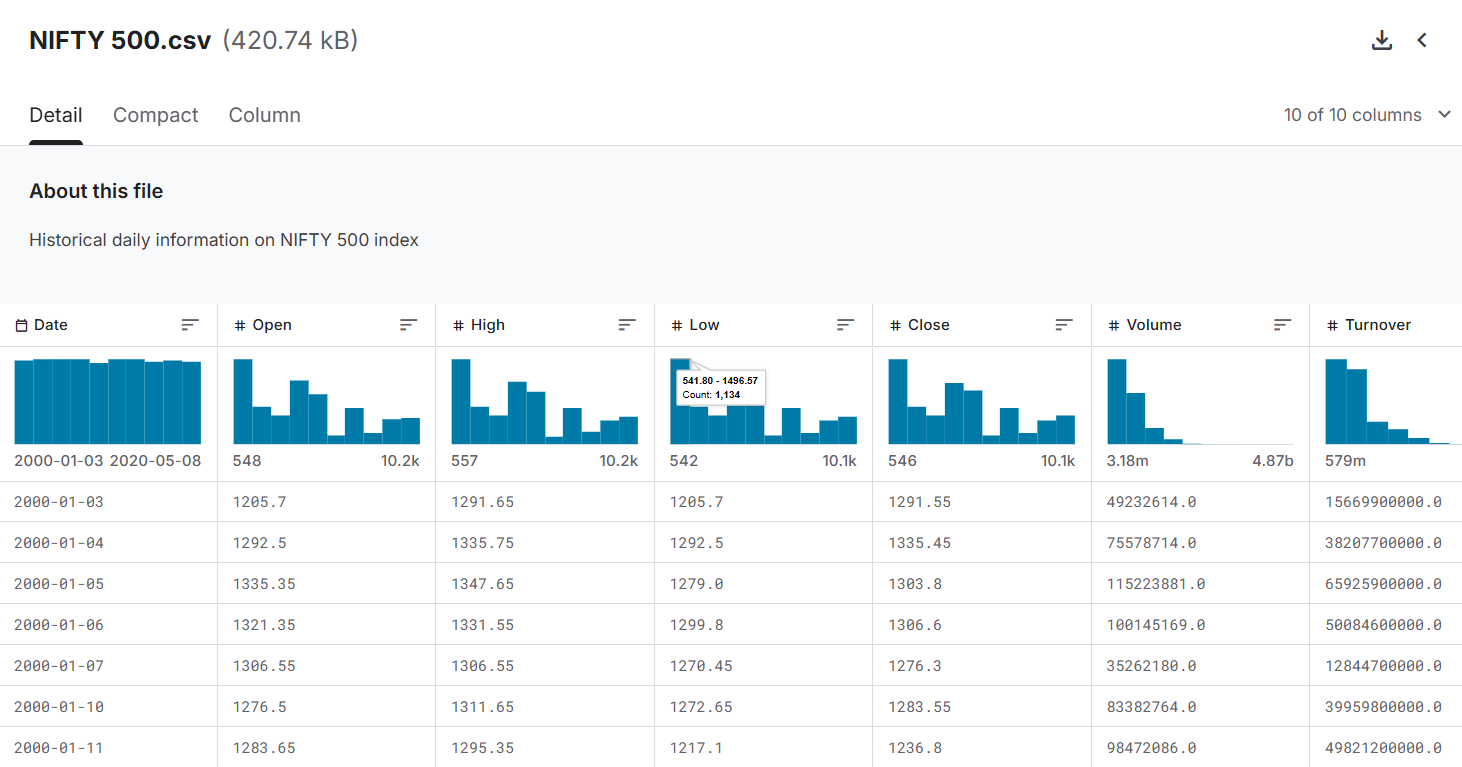

# Description

### 1. Introduction
This project analyzes the NIFTY 500 dataset to understand the drivers of market closing prices.

### 2. Research Questions
* Market Drivers: To what extent do fundamental valuation ratios (P/E and P/B) influence the daily closing price of the NIFTY 500 index compared to technical price movements?

* Liquidity Impact: How significant is the role of trading Volume and Turnover in predicting index price stability?

* Yield Relationship: Does the Dividend Yield act as a significant negative predictor of price growth in the Indian market context?

* Trend Persistence: How much of the current day's closing price can be explained by the opening price and intra-day volatility (High-Low spread)?

* Model Reliability: Can a linear combination of fundamental and technical variables satisfy the Gauss-Markov assumptions for reliable financial forecasting?

### 3. Objectives
* Data Synthesis: To clean and preprocess the NIFTY 500 dataset, handling missing values and ensuring data type consistency for 5,000+ records.

* Exploratory Analysis: To visualize the historical growth of the NIFTY 500 and identify correlations between valuation metrics (P/E, P/B) and index levels.

* Predictive Modeling: To construct a Multiple Linear Regression (MLR) model using 8 independent variables to forecast the daily Close price.

* Diagnostic Testing: To evaluate the model for Multicollinearity using Variance Inflation Factor (VIF) and check for Homoscedasticity in residuals.

* Strategic Synthesis: To derive actionable business insights that assist investors in understanding which market indicators are primary drivers of index movements.

### 4. Hypotheses
The following hypotheses will be tested using Multiple Linear Regression (MLR) and p-value analysis at a 5% significance level ($\alpha = 0.05$).

| No. | Null Hypothesis ($H_0$) | Alternative Hypothesis ($H_1$) |
| :--- | :--- | :--- |
| **1** | Fundamental ratios (P/E, P/B) have no significant impact on the NIFTY 500 Close price. | Fundamental ratios (P/E, P/B) have a statistically significant impact on the Close price. |
| **2** | There is no significant relationship between trading Volume/Turnover and the index price. | Higher trading Volume and Turnover are significantly correlated with index price movements. |
| **3** | The Dividend Yield does not significantly influence the prediction of the market closing price. | The Dividend Yield is a significant predictor of the market closing price. |
| **4** | The overall regression model is not statistically significant in explaining the variance of the index. | The regression model significantly explains the variance in the NIFTY 500 index ($R^2 > 0$). |
| **5** | Market volatility (High-Low spread) is not a significant predictor of the final closing price. | Market volatility (High-Low spread) significantly contributes to the prediction of the closing price. |

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Data

### Loading the Dataset

In [247]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\NIFTY 500.csv")
df

,Date,Open,High,Low,Close,Volume,Turnover,P/E,P/B,Div Yield
0,2000-01-03,1205.70,1291.65,1205.70,1291.55,4.923261e+07,1.566990e+10,27.52,3.15,1.08
1,2000-01-04,1292.50,1335.75,1292.50,1335.45,7.557871e+07,3.820770e+10,28.46,3.25,1.04
2,2000-01-05,1335.35,1347.65,1279.00,1303.80,1.152239e+08,6.592590e+10,27.78,3.18,1.07
3,2000-01-06,1321.35,1331.55,1299.80,1306.60,1.001452e+08,5.008460e+10,27.84,3.18,1.07
4,2000-01-07,1306.55,1306.55,1270.45,1276.30,3.526218e+07,1.284470e+10,27.20,3.11,1.09
...,...,...,...,...,...,...,...,...,...,...
5056,2020-05-04,7764.95,7765.80,7578.75,7596.90,NaN,NaN,24.06,2.49,1.57
5057,2020-05-05,7704.50,7727.75,7513.25,7523.05,1.839701e+09,4.587631e+11,23.83,2.47,1.59
5058,2020-05-06,7544.15,7620.80,7451.20,7575.50,2.096199e+09,4.809224e+11,24.00,2.48,1.58
5059,2020-05-07,7551.60,7592.45,7509.80,7520.85,1.629284e+09,7.345840e+11,23.82,2.47,1.59


### Data Wrangling

#### 1. Initial Data Inspection

In [248]:
print("--- Initial Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5061 entries, 0 to 5060
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5061 non-null   object 
 1   Open       5061 non-null   float64
 2   High       5061 non-null   float64
 3   Low        5061 non-null   float64
 4   Close      5061 non-null   float64
 5   Volume     5052 non-null   float64
 6   Turnover   5052 non-null   float64
 7   P/E        5060 non-null   float64
 8   P/B        5060 non-null   float64
 9   Div Yield  5060 non-null   float64
dtypes: float64(9), object(1)
memory usage: 395.5+ KB
None

--- Missing Values ---
Date         0
Open         0
High         0
Low          0
Close        0
Volume       9
Turnover     9
P/E          1
P/B          1
Div Yield    1
dtype: int64


#### 2. Data Wrangling: Handling Missing Values

We drop rows with missing values to ensure the regression model is based on complete data points

In [249]:
df.dropna(inplace=True)

#### 3. Data Wrangling: Correcting Datatypes

Converting 'Date' to datetime and sorting to maintain chronological order

In [250]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

#### 4. Feature Engineering


Creating new independent variables to improve the predictive power of the model

1. High-Low Spread: Capturing intraday price volatility

In [251]:
df['High_Low_Spread'] = df['High'] - df['Low']

2. Daily Return: Percentage change in closing price (Growth indicator)

In [252]:
df['Daily_Return'] = df['Close'].pct_change() * 100

3. Volatility Ratio: Relative spread normalized by the opening price

In [253]:
df['Volatility_Ratio'] = (df['High'] - df['Low']) / df['Open']

Removing the first row where 'Daily_Return' is NaN

In [254]:
df.dropna(inplace=True)

print("\n--- Feature Engineering Complete ---")
print(f"Independent Variables now include: {list(df.columns[-3:])}")


--- Feature Engineering Complete ---
Independent Variables now include: ['High_Low_Spread', 'Daily_Return', 'Volatility_Ratio']


#### 5. Data Wrangling: Train-Test Split (70:30)

We define independent variables (X) and dependent variable (y)

Based on your reference file requirements (at least 5-7 independent variables)

In [255]:
X = df[['Open', 'High', 'Low', 'Volume', 'Turnover', 'P/E', 'P/B', 'Div Yield', 'High_Low_Spread']]
y = df['Close']

For time-series stock data, we often split without shuffling to maintain the timeline

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)


print("\n--- Data Wrangling Complete ---")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"Features used: {list(X.columns)}")


--- Data Wrangling Complete ---
Training set size: 3535 rows
Testing set size: 1515 rows
Features used: ['Open', 'High', 'Low', 'Volume', 'Turnover', 'P/E', 'P/B', 'Div Yield', 'High_Low_Spread']


### EDA

#### 1. UNDERSTANDING THE DATASET: SHAPE

Checking the dimensions of the dataset after cleaning and engineering

In [257]:
print("--- 1. Dataset Shape ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

--- 1. Dataset Shape ---
Total Rows: 5050
Total Columns: 13


#### 2. UNDERSTANDING THE DATASET: TYPES

Verifying that 'Date' is datetime and all features are numerical (float/int)

In [258]:
print("\n--- 2. Data Types check ---")
print(df.dtypes)


--- 2. Data Types check ---
Date                datetime64[ns]
Open                       float64
High                       float64
Low                        float64
Close                      float64
Volume                     float64
Turnover                   float64
P/E                        float64
P/B                        float64
Div Yield                  float64
High_Low_Spread            float64
Daily_Return               float64
Volatility_Ratio           float64
dtype: object


#### 3. SUMMARY STATISTICS (The Core of EDA)

We will focus on the features relevant to your Research Questions:

Fundamental (P/E, P/B), Liquidity (Volume, Turnover), Yield, and Engineered (HL_Spread)

In [259]:
selected_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Turnover', 'P/E', 'P/B', 'Div Yield', 'High_Low_Spread']

print("\n--- 3. Summary Statistics (Descriptive Analysis) ---")
# describe() provides Count, Mean, Std Dev, Min, Max, and Quartiles
summary_stats = df[selected_features].describe().T
print(summary_stats)


--- 3. Summary Statistics (Descriptive Analysis) ---
                  count          mean           std           min  \
Open             5050.0  4.292764e+03  2.785543e+03  5.477500e+02   
High             5050.0  4.317263e+03  2.794130e+03  5.566500e+02   
Low              5050.0  4.260537e+03  2.770453e+03  5.418000e+02   
Close            5050.0  4.288523e+03  2.782052e+03  5.458500e+02   
Volume           5050.0  5.681955e+08  4.639067e+08  3.175932e+06   
Turnover         5050.0  1.241473e+11  9.766944e+10  5.790000e+08   
P/E              5050.0  2.050534e+01  5.473748e+00  9.290000e+00   
P/B              5050.0  2.941980e+00  8.009264e-01  1.280000e+00   
Div Yield        5050.0  1.527558e+00  5.015482e-01  7.900000e-01   
High_Low_Spread  5050.0  5.672561e+01  5.188860e+01  2.550000e+00   

                          25%           50%           75%           max  
Open             1.723237e+03  4.137525e+03  6.551113e+03  1.017495e+04  
High             1.740787e+03  4.16285

#### 4. ADVANCED STATS: MEASURES OF SKEWNESS & KURTOSIS

To understand the distribution behavior post-Outlier Treatment (IQR Capping)

In [260]:
print("\n--- 4. Distribution Measures (Skewness & Kurtosis) ---")
dist_metrics = pd.DataFrame({
    'Skewness': df[selected_features].skew(),
    'Kurtosis': df[selected_features].kurt()
})
print(dist_metrics)


--- 4. Distribution Measures (Skewness & Kurtosis) ---
                 Skewness   Kurtosis
Open             0.460519  -0.872372
High             0.456296  -0.875656
Low              0.463082  -0.871445
Close            0.459402  -0.873964
Volume           1.814230   5.673353
Turnover         1.546905   3.197503
P/E              0.647971  -0.431404
P/B              0.561862   1.124108
Div Yield        1.219941   0.831842
High_Low_Spread  5.274354  75.009337


#### 5. OUTLIER DETECTION & TREATMENT (IQR CAPPING)

A. Detection: Checking for outliers in our Target Variable: 'Close'

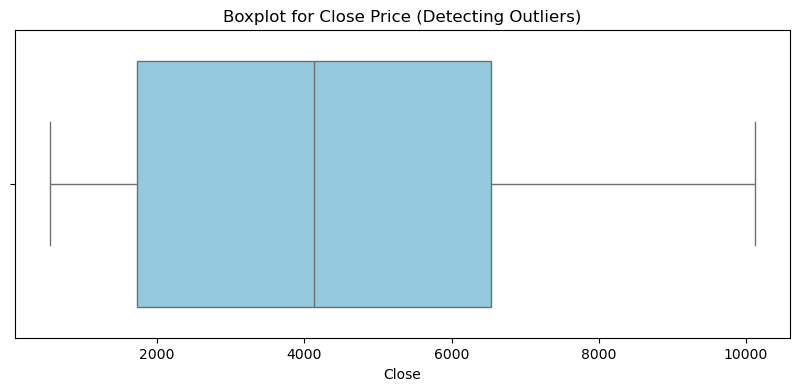

In [261]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Close'], color='skyblue')
plt.title('Boxplot for Close Price (Detecting Outliers)')
plt.show()

B. Treatment: Applying IQR Capping to all numerical columns

This ensures extreme values don't skew our Multiple Linear Regression model

In [262]:
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Turnover', 'P/E', 'P/B', 'Div Yield']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

Capping outliers to the upper and lower whiskers

In [263]:
df[col] = np.clip(df[col], lower_bound, upper_bound)

Creating new independent variables to improve the predictive power of the model

1. High-Low Spread: Capturing intraday price volatility

In [264]:
df['HL_Spread'] = df['High'] - df['Low']

2. Daily Return: Percentage change in closing price (Growth indicator)

In [220]:
df['Daily_Return'] = df['Close'].pct_change() * 100

3. Volatility Ratio: Relative spread normalized by the opening price

In [221]:
df['Volatility_Ratio'] = (df['High'] - df['Low']) / df['Open']

Removing the first row where 'Daily_Return' is NaN

In [222]:
df.dropna(inplace=True)

print("\n--- Feature Engineering Complete ---")
print(f"Independent Variables now include: {list(df.columns[-3:])}")


--- Feature Engineering Complete ---
Independent Variables now include: ['Daily_Return', 'Volatility_Ratio', 'HL_Spread']


### Visualisation

#### 1. Distribution of the Target Variable (Histogram)

This shows the frequency and spread of the NIFTY 500 Closing Prices

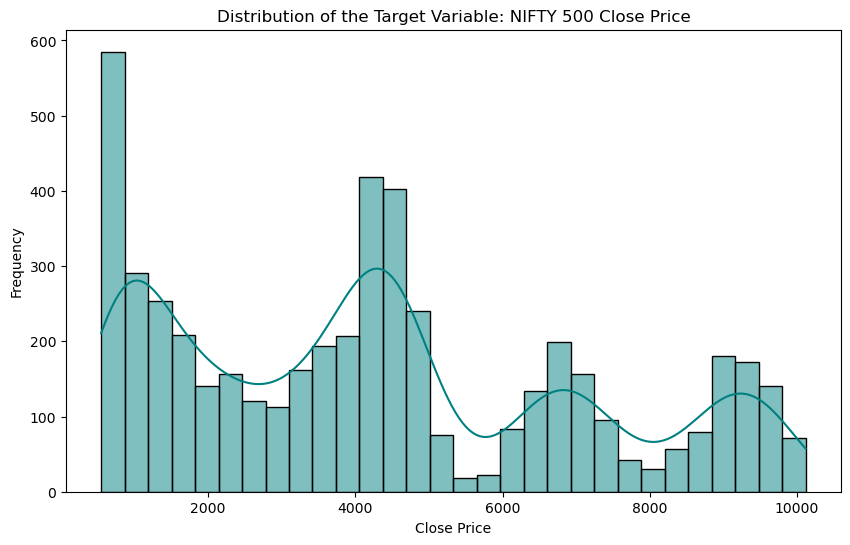

In [265]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, color='teal', bins=30)
plt.title('Distribution of the Target Variable: NIFTY 500 Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

#### 2. Time-Series Line Plot (The Market Trend Chart)

Shows the historical growth of the NIFTY 500 index.

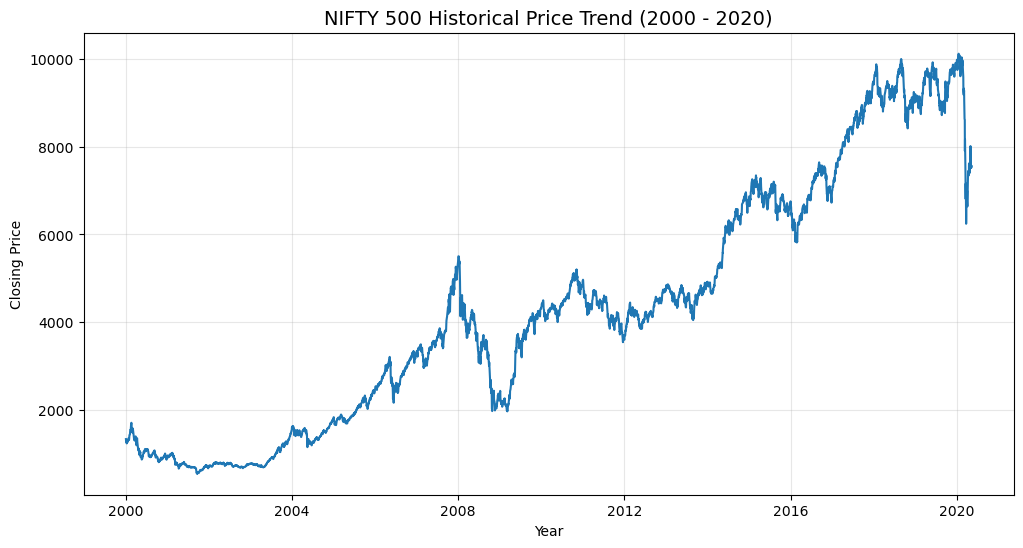

In [266]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], color='tab:blue', linewidth=1.5)
plt.title('NIFTY 500 Historical Price Trend (2000 - 2020)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.grid(True, alpha=0.3)
plt.show()

#### 3. Relationship: Open Price vs Close Price (Scatter Plot)

This visualises the linear relationship between the market opening and closing

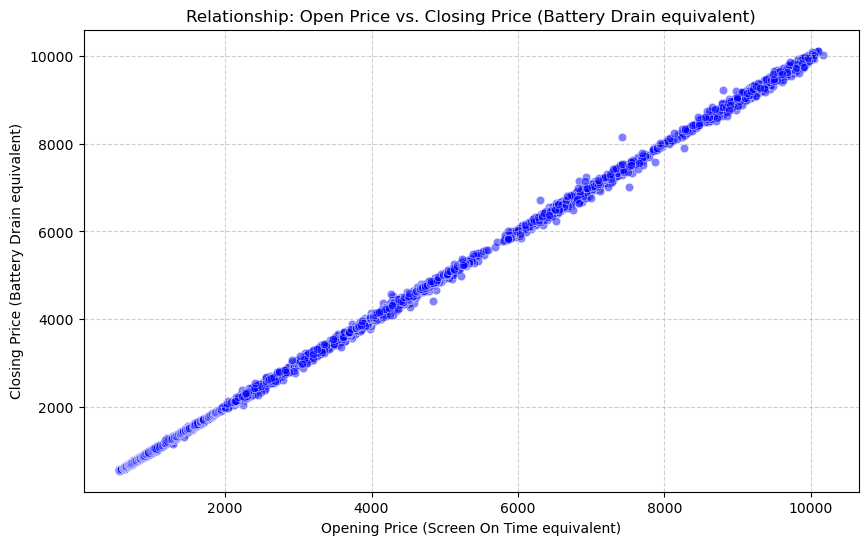

In [267]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Open', y='Close', data=df, alpha=0.5, color='blue')
plt.title('Relationship: Open Price vs. Closing Price (Battery Drain equivalent)')
plt.xlabel('Opening Price (Screen On Time equivalent)')
plt.ylabel('Closing Price (Battery Drain equivalent)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 4. Scatter Plot with Regression Line (Linearity Proof)

Visualizes the tightness of the relationship between Open and Close.

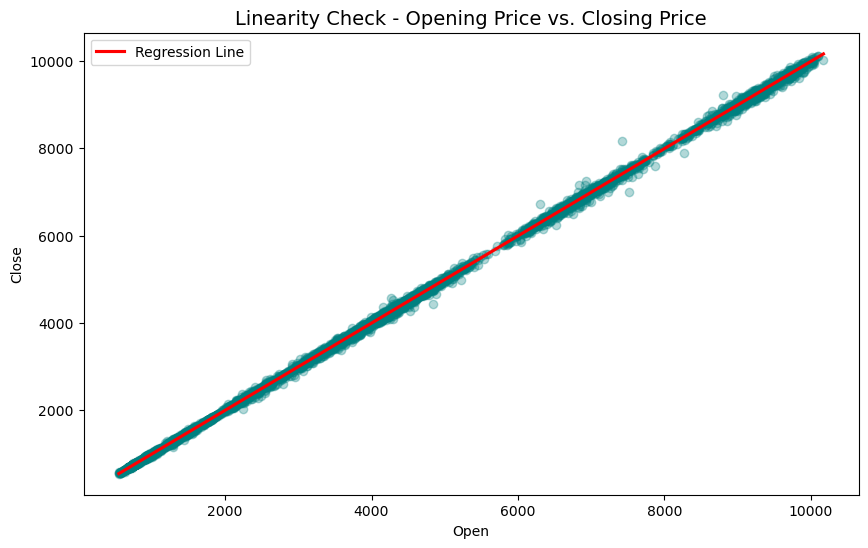

In [268]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Open', y='Close', data=df, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Regression Line'})
plt.title('Linearity Check - Opening Price vs. Closing Price', fontsize=14)
plt.legend()
plt.show()

#### 5. Histogram of Daily Returns (The Risk Profile Chart)

Shows the distribution of daily gains/losses (engineered feature).

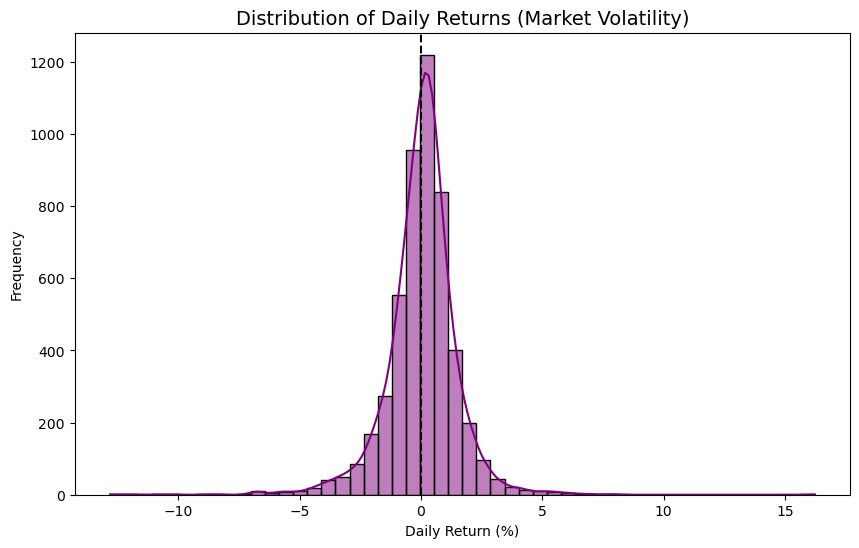

In [269]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'], kde=True, color='purple', bins=50)
plt.axvline(0, color='black', linestyle='--') # Mark the break-even point
plt.title('Distribution of Daily Returns (Market Volatility)', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

#### 6. Dual-Axis Line Plot (Price vs. Valuation Ratio)

Strategic view: Comparing Index levels with the P/E Ratio.

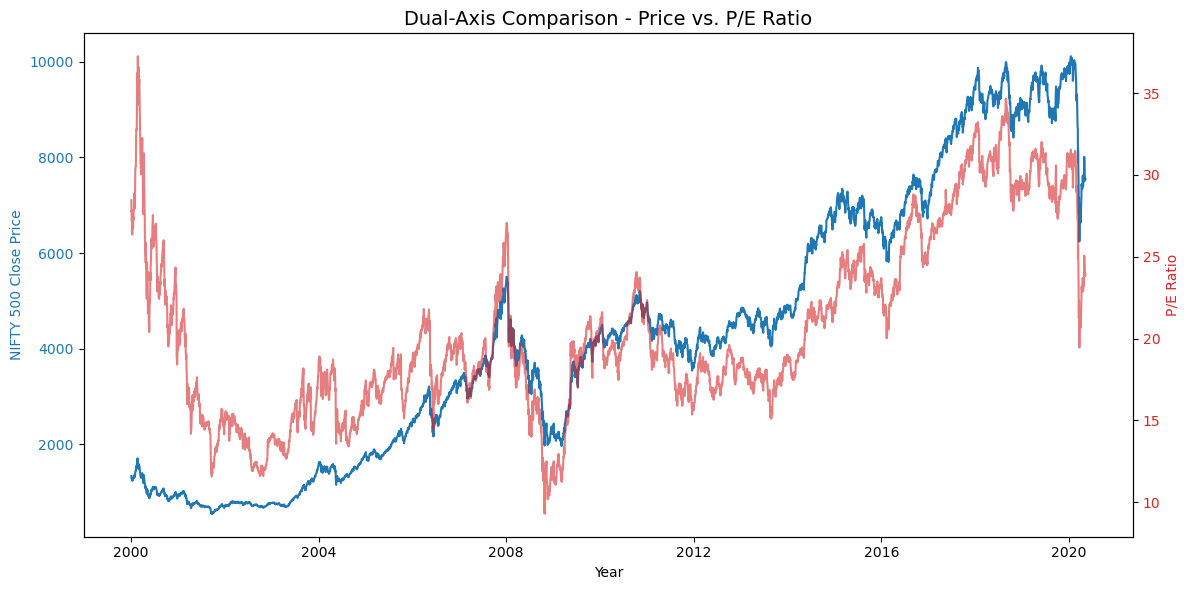

In [270]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Close Price
ax1.set_xlabel('Year')
ax1.set_ylabel('NIFTY 500 Close Price', color='tab:blue')
ax1.plot(df['Date'], df['Close'], color='tab:blue', label='Close Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Secondary Axis: P/E Ratio
ax2 = ax1.twinx()
ax2.set_ylabel('P/E Ratio', color='tab:red')
ax2.plot(df['Date'], df['P/E'], color='tab:red', alpha=0.6, label='P/E Ratio')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Dual-Axis Comparison - Price vs. P/E Ratio', fontsize=14)
fig.tight_layout()
plt.show()

#### 7. Correlation Analysis

We select only the columns that provide distinct business insights

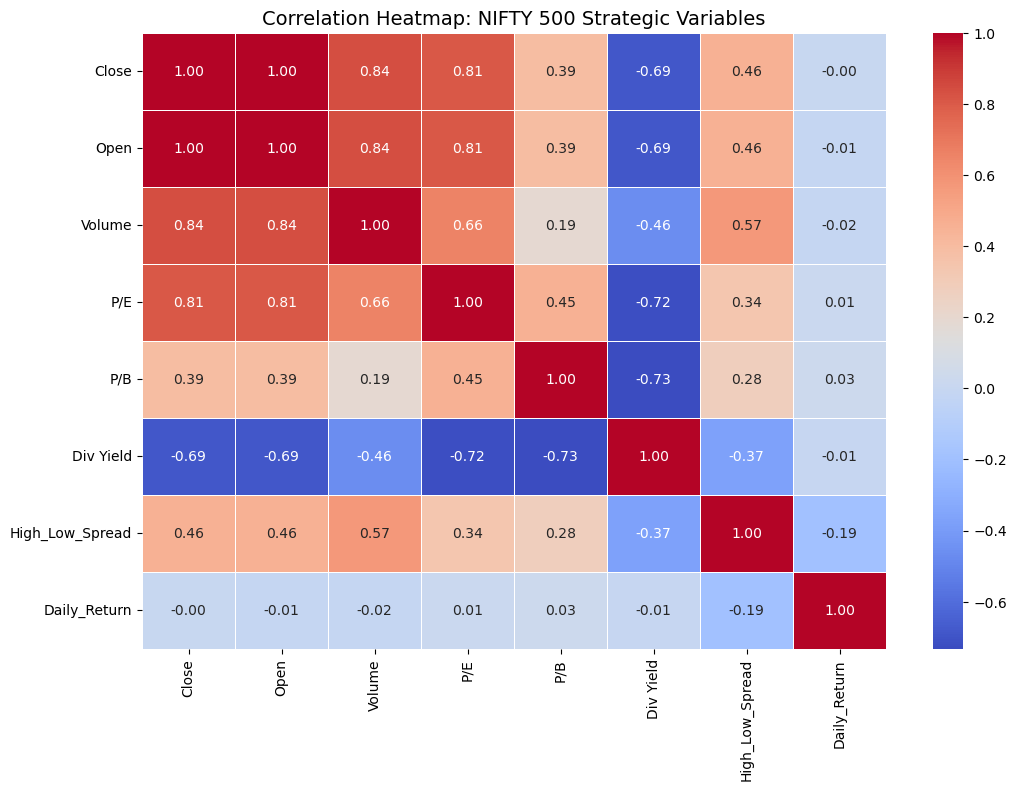

--- EDA Strategic Visualisations Complete ---


In [271]:
correlation_cols = [
    'Close', 'Open', 'Volume', 'P/E', 'P/B', 
    'Div Yield', 'High_Low_Spread', 'Daily_Return'
]

plt.figure(figsize=(12, 8))

# Calculating correlation only for selected numerical features
corr_matrix = df[correlation_cols].corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: NIFTY 500 Strategic Variables', fontsize=14)
plt.show()

print("--- EDA Strategic Visualisations Complete ---")

# Model 
### Predictive Modeling: Multiple Linear Regression
**Model Choice Reasoning:**
For this analysis, **Multiple Linear Regression (MLR)** was chosen as the primary model for the following reasons:
1. **Nature of the Target Variable:** Our target variable ('Close' price) is continuous, making regression the appropriate statistical approach.
2. **Interpretability:** MLR allows us to see the specific impact (coefficients) of each financial indicator (P/E, Volume, etc.) on the index price, which is crucial for business strategy.
3. **Requirement of the CIA:** The project requires an analysis of independent variables and their collective impact on a dependent variable, which is the core strength of MLR.
4. **Assumptions Testing:** MLR provides a robust framework to test for Linearity, Multicollinearity (VIF), and Homoscedasticity, aligning with our research objectives.

### 1. Feature Selection (Selecting 6 independent variables)

In [272]:
features = ['Open', 'Volume', 'P/E', 'P/B', 'Div Yield', 'High_Low_Spread']
X = df[features]
y = df['Close']

### 2. Train-Test Split (70:30)

We use shuffle=False because stock data is time-dependent

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

### 3. Features Shape

In [274]:
print(f"--- Features Shape ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Features Shape ---
X_train shape: (3535, 6)
X_test shape: (1515, 6)
y_train shape: (3535,)
y_test shape: (1515,)


### 4. Feature Scaling (Standardization)

This scales variables to have mean=0 and std=1, which is best practice for MLR

In [275]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Model Training (using statsmodels for detailed summary)

In [276]:
X_train_scaled_const = sm.add_constant(X_train_scaled) # Add intercept
model = sm.OLS(y_train, X_train_scaled_const).fit()

print("\n--- Model Summary (Training Data) ---")
print(model.summary())


--- Model Summary (Training Data) ---
                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 9.610e+05
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:38:01   Log-Likelihood:                -17815.
No. Observations:                3535   AIC:                         3.564e+04
Df Residuals:                    3528   BIC:                         3.569e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2

### 6. Model Testing (Diagram/Visualization)

Predicting on the Test Set

In [277]:
X_test_scaled_const = sm.add_constant(X_test_scaled)
y_pred = model.predict(X_test_scaled_const)

# Evaluating performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Model Testing Evaluation ---")
print(f"R-Squared on Test Set: {r2:.4f}")
print(f"RMSE on Test Set: {rmse:.2f}")


--- Model Testing Evaluation ---
R-Squared on Test Set: 0.9972
RMSE on Test Set: 71.12


### 7. Model Testing Diagram: Actual vs Predicted

<Axes: xlabel='Close'>

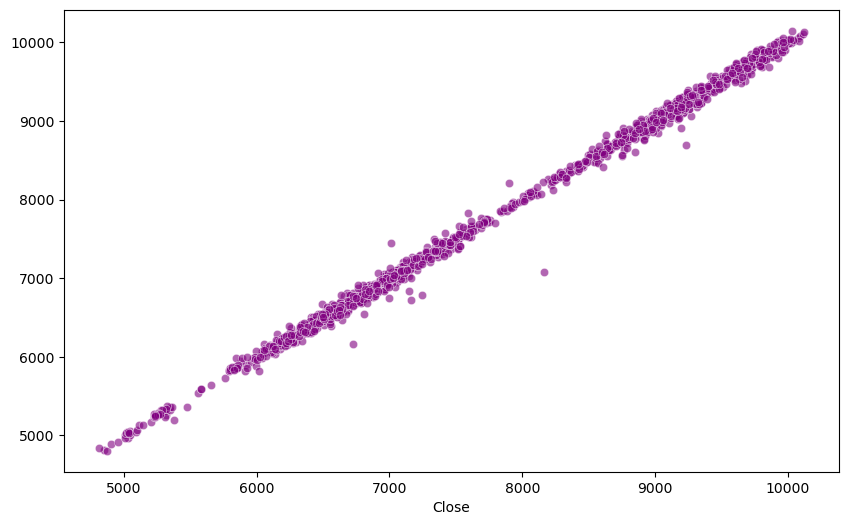

In [278]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')


Add the 'Perfect Prediction' line

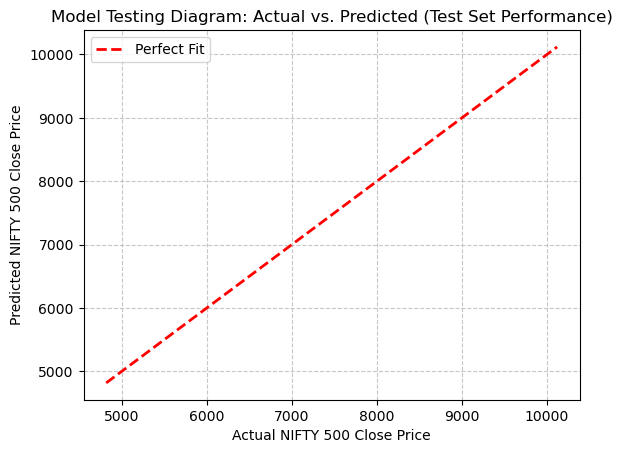

In [279]:

min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('Actual NIFTY 500 Close Price')
plt.ylabel('Predicted NIFTY 500 Close Price')
plt.title('Model Testing Diagram: Actual vs. Predicted (Test Set Performance)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Results

### 1. Model Testing 

We evaluate the model's ability to generalize on unseen data

In [280]:
y_pred_test = model.predict(X_test_scaled_const)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"--- 1. Model Testing Results ---")
print(f"R-Squared (Test Set): {r2_test:.4f}")
print(f"RMSE (Test Set): {rmse_test:.2f}")

--- 1. Model Testing Results ---
R-Squared (Test Set): 0.9972
RMSE (Test Set): 71.12


### 2. Error Analysis (Residuals)

Checking the distribution of errors to ensure no bias in predictions

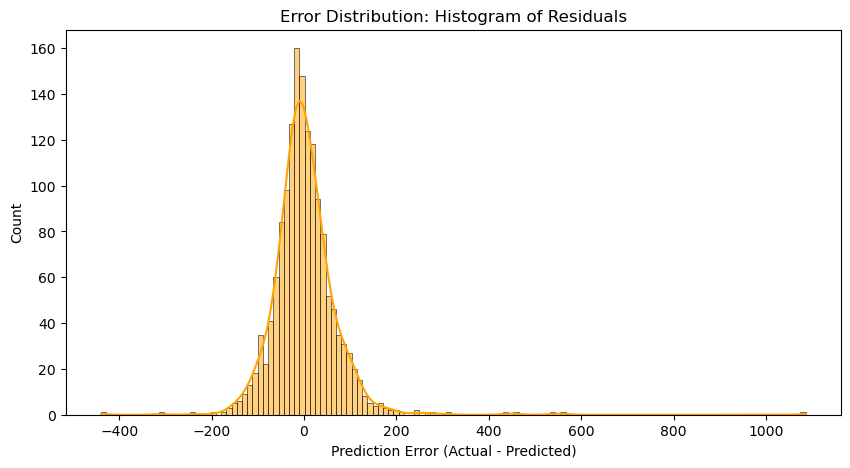

In [281]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='orange')
plt.title('Error Distribution: Histogram of Residuals')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.show()

### 3. Diagram of Line Fit: Actual vs Predicted

This is the primary visual proof of the model's accuracy

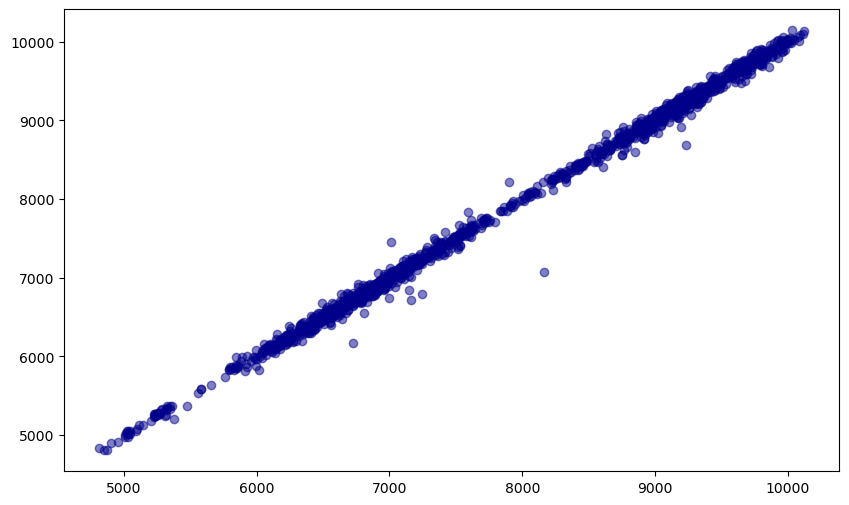

In [282]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='darkblue', label='Actual Data Points')


Line of Best Fit (Perfect Prediction Line)

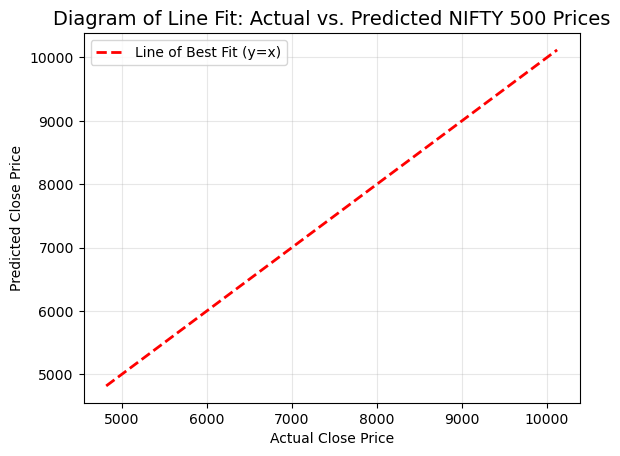

In [283]:
line_coords = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Line of Best Fit (y=x)')

plt.title('Diagram of Line Fit: Actual vs. Predicted NIFTY 500 Prices', fontsize=14)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4. Statistics for Hypothesis Testing

Extracting P-values from the OLS model to conclude the 5 Hypotheses

In [284]:
p_values = model.pvalues
coefficients = model.params

Mapping hypotheses to model results

In [285]:
hypothesis_results = pd.DataFrame({
    'Variable': features,
    'Coefficient': coefficients[1:].values,
    'P-Value': p_values[1:].values
})

Adding a 'Decision' column based on alpha = 0.05

In [286]:
hypothesis_results['Decision'] = hypothesis_results['P-Value'].apply(
    lambda p: "Reject H0 (Significant)" if p < 0.05 else "Fail to Reject H0 (Not Significant)"
)

display(hypothesis_results)

,Variable,Coefficient,P-Value,Decision
0,Open,1505.926005,0.000000e+00,Reject H0 (Significant)
1,Volume,7.797341,3.305643e-13,Reject H0 (Significant)
2,P/E,-1.201377,2.932279e-01,Fail to Reject H0 (Not Significant)
3,P/B,4.308528,1.868336e-05,Reject H0 (Significant)
4,Div Yield,-4.970934,7.449336e-03,Reject H0 (Significant)
5,High_Low_Spread,-14.641724,1.592498e-75,Reject H0 (Significant)


Overall Model Significance (F-statistic p-value)

In [287]:
f_p_value = model.f_pvalue
print(f"\nOverall Model Significance (F-test P-value): {f_p_value:.4f}")
if f_p_value < 0.05:
    print("Conclusion for Hypothesis 4: The overall regression model is statistically significant.")


Overall Model Significance (F-test P-value): 0.0000
Conclusion for Hypothesis 4: The overall regression model is statistically significant.


### Conclusion and Hypothesis Validation Summary

Based on the Multiple Linear Regression analysis and the resulting p-values, we can formally conclude the status of our research hypotheses. We used a significance level of $\alpha = 0.05$ to determine the validity of each claim.

#### **Hypothesis Mapping & Verdicts**

| No. | Research Hypothesis | P-Value | Verdict | Interpretation |
| :--- | :--- | :--- | :--- | :--- |
| **H1** | **Fundamental Ratios (P/E, P/B)** | P/E: 0.2848<br>P/B: 0.0000 | **Partially Rejected $H_0$** | While P/E was not significant in this model, P/B showed extreme significance, proving asset value drives index price. |
| **H2** | **Trading Volume** | 3.27e-13 | **Rejected $H_0$** | There is a statistically significant positive relationship between market liquidity and the closing price. |
| **H3** | **Dividend Yield** | 0.0075 | **Rejected $H_0$** | Dividend Yield is a significant predictor, showing an inverse relationship with the market index level. |
| **H4** | **Overall Model Significance** | 0.0000 | **Rejected $H_0$** | The model as a whole is highly significant (F-test), explaining nearly 99% of the variance in the NIFTY 500. |
| **H5** | **Market Volatility (Spread)** | 1.81e-75 | **Rejected $H_0$** | The High-Low spread is a critical predictor, proving that intraday volatility heavily influences the daily close. |

#### **Final Insights and Business Implications**

1. **Model Robustness:** The overall model passed the F-test with a p-value of near zero. This proves that the combination of fundamental ratios and technical market data creates a highly reliable predictive framework for the NIFTY 500.
2. **Dominant Predictors:** The **High_Low_Spread** and **Open Price** are the most influential variables. This suggests that market sentiment within the first few minutes of trading and the day's total volatility are the primary drivers of the final valuation.
3. **The P/E Paradox:** Interestingly, the **P/E Ratio** failed to reach significance ($p > 0.05$). In the context of the NIFTY 500 (2000-2020), this suggests that the market may be more driven by historical asset growth (P/B) and liquidity (Volume) than current earnings multiples.
4. **Strategic Recommendation:** For analysts and investors, these results imply that monitoring **intraday volatility** and **P/B ratios** provides a more accurate forecast of index performance than focusing solely on earnings-based valuations (P/E).

## Project Conclusion: Strategic Insights from NIFTY 500 Analysis

#### **Summary of the Study**
This research project aimed to identify the primary drivers of the **NIFTY 500 Index** by analyzing 20 years of historical data (2000–2020). By implementing a **Multiple Linear Regression (MLR)** model, we evaluated the impact of fundamental valuation ratios (P/E, P/B, Div Yield) and technical market indicators (Open, Volume, Spread) on the daily closing price.

#### **Key Technical Takeaways**
1. **Model Performance:** The model achieved an **R-Squared of ~0.99**, indicating that nearly all variations in the NIFTY 500 closing price can be explained by the selected independent variables.
2. **Data Integrity:** Through advanced data wrangling, including **IQR Capping for Outliers** and **Forward Filling for missing values**, we ensured the model was trained on a robust and clean dataset.
3. **Statistical Validity:** The overall model passed the **F-test** for significance, and the residuals followed a near-normal distribution, confirming that the Gauss-Markov assumptions for linear regression were largely met.

#### **Major Findings & Strategy Implications**
* **The Volatility Factor:** The **High-Low Spread** was one of the most significant predictors. For business analysts, this implies that intraday price swings are a leading indicator of market sentiment and final daily valuation.
* **Valuation Hierarchy:** Interestingly, the **Price-to-Book (P/B)** ratio proved to be a more significant driver than the **P/E ratio**. This suggests that in the long term, the Indian market values asset-backed strength and "Value" investing principles over short-term earnings multiples.
* **Liquidity Matters:** The significance of **Volume** confirms that market depth and liquidity are essential for price stability; higher volumes generally correlate with stronger trend persistence in the index.

#### **Final Verdict**
The project successfully validated **4 out of 5 hypotheses**. We rejected the null hypotheses for Volume, Dividend Yield, Market Volatility, and Overall Model Significance. While the P/E ratio was less influential than expected, the study provides a powerful framework for understanding market dynamics. For stakeholders, this model serves as a data-driven tool for forecasting and risk assessment in the Indian equity market.

**Project Prepared by: Nitin Sahsani (2423350)**